# Project KALM: Kalman-based Adaptive Linear Modeling

**Objective:** Use a Kalman filter to estimate a clean, time-varying random signal from noisy measurements.

This notebook leverages **PySDR** for noise generation and analysis.


## 1. Import Required Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
#from pysdr import spectrum

# Custom utils
import sys
sys.path.append('../src')
from utils import *

## 2. Simulate Time-Varying Noisy Signal

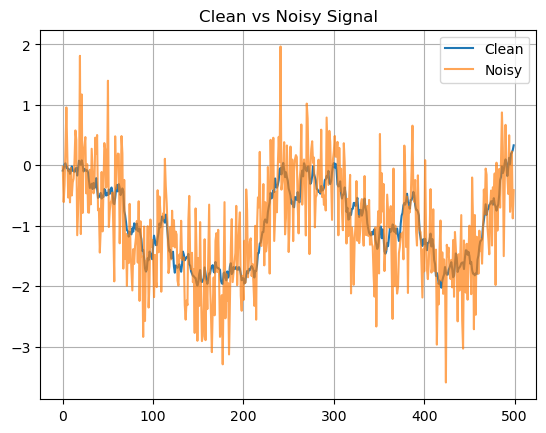

In [3]:
# TODO: Simulate a random walk (or similar) dynamic process
N = 500
clean_signal = np.cumsum(np.random.normal(0, 0.1, N))  # random walk

# Add noise
noisy_signal = add_awgn_noise(clean_signal, snr_db=5)

plt.figure()
plt.plot(clean_signal, label='Clean')
plt.plot(noisy_signal, label='Noisy', alpha=0.7)
plt.legend()
plt.title('Clean vs Noisy Signal')
plt.grid()
plt.show()

## 3. Implement Kalman Filter

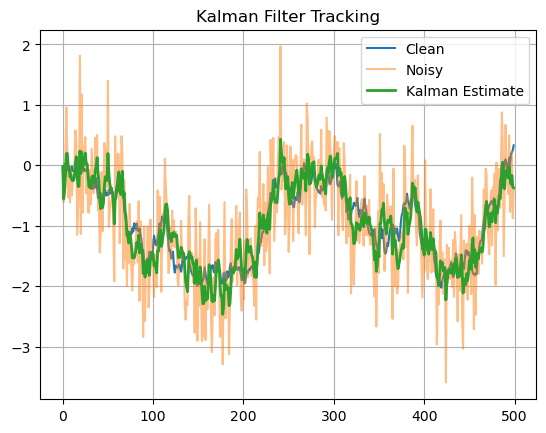

In [4]:
# TODO: Implement a simple Kalman filter for 1D tracking
# Initialize variables
x_est = np.zeros(N)
P = np.zeros(N)
Q = 0.01  # process noise covariance
R = 0.1   # measurement noise covariance
x_est[0] = noisy_signal[0]
P[0] = 1

for k in range(1, N):
    # Predict
    x_pred = x_est[k-1]
    P_pred = P[k-1] + Q

    # Update
    K = P_pred / (P_pred + R)
    x_est[k] = x_pred + K * (noisy_signal[k] - x_pred)
    P[k] = (1 - K) * P_pred

plt.figure()
plt.plot(clean_signal, label='Clean')
plt.plot(noisy_signal, label='Noisy', alpha=0.5)
plt.plot(x_est, label='Kalman Estimate', linewidth=2)
plt.legend()
plt.title('Kalman Filter Tracking')
plt.grid()
plt.show()

## 4. Error Convergence Visualization

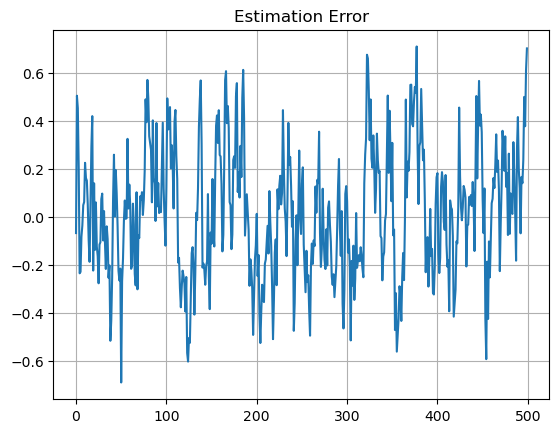

In [5]:
error = clean_signal - x_est
plt.figure()
plt.plot(error)
plt.title('Estimation Error')
plt.grid()
plt.show()

## 5. Reflection
- How does the Kalman filter adapt to the noisy measurements?
- Real-world applications: tracking, sensor fusion, etc.